In [12]:
import pandas as pd

def extract_netflix_data():
    # URL to the TidyTuesday Netflix dataset
    url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-04-20/netflix_titles.csv"
    
    # Load raw data
    raw_df = pd.read_csv(url)
    
    # --- CLEANING ---
    # 1. Clean the 'date_added' column and create numeric years
    raw_df['date_added'] = pd.to_datetime(raw_df['date_added'].str.strip(), errors='coerce')
    raw_df['year_added'] = raw_df['date_added'].dt.year
    
    # 2. Fill missing values to prevent errors during plotting
    raw_df['country'] = raw_df['country'].fillna('Unknown')
    raw_df['director'] = raw_df['director'].fillna('Unknown')
    raw_df['cast'] = raw_df['cast'].fillna('Unknown')
    
    # 3. Extract movie duration as an integer (minutes)
    # This filters out 'Seasons' for TV shows to keep the numbers clean
    raw_df['duration_min'] = raw_df['duration'].str.extract(r'(\d+)').astype(float)
    
    return raw_df

# Execute extraction
df = extract_netflix_data()
print(f"Successfully extracted {len(df)} titles.")

Successfully extracted 7787 titles.


In [ ]:
genres_df = df.copy()
genres_df['listed_in'] = genres_df['listed_in'].str.split(', ')
exploded_genres = genres_df.explode('listed_in')

print("Top 5 Genres:")
print(exploded_genres['listed_in'].value_counts().head(5))


countries_df = df.copy()
countries_df['country'] = countries_df['country'].str.split(', ')
exploded_countries = countries_df.explode('country')

print("\nTop 5 Countries:")
print(exploded_countries['country'].value_counts().head(5))

Top 5 Genres:
listed_in
International Movies      2437
Dramas                    2106
Comedies                  1471
International TV Shows    1199
Documentaries              786
Name: count, dtype: int64

Top 5 Countries:
country
United States     3296
India              990
United Kingdom     722
Unknown            507
Canada             412
Name: count, dtype: int64


In [14]:
# Save the cleaned main dataframe
df.to_csv('netflix_cleaned_data.csv', index=False)

# Save the exploded versions for specific deep-dives
exploded_genres.to_csv('netflix_genres_only.csv', index=False)
exploded_countries.to_csv('netflix_countries_only.csv', index=False)

print("Files saved to local directory.")

Files saved to local directory.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# THEME COLORS
CREAM, PEACH, BERRY_PINK = "#F9F7F2", "#F9B7A2", "#EC628D"
ORCHID, GRAPE, PLUM_DARK = "#A33B91", "#6B217D", "#2D0B33"

# DATA LOADING
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-04-20/netflix_titles.csv"
df = pd.read_csv(url)

# PRE-PROCESSING
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['country'] = df['country'].fillna('Unknown')

def apply_berry_style(ax, title):
    ax.set_facecolor(CREAM)
    ax.set_title(title.upper(), fontsize=14, fontweight='900', color=PLUM_DARK, loc='left', pad=15)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color(PLUM_DARK)
    

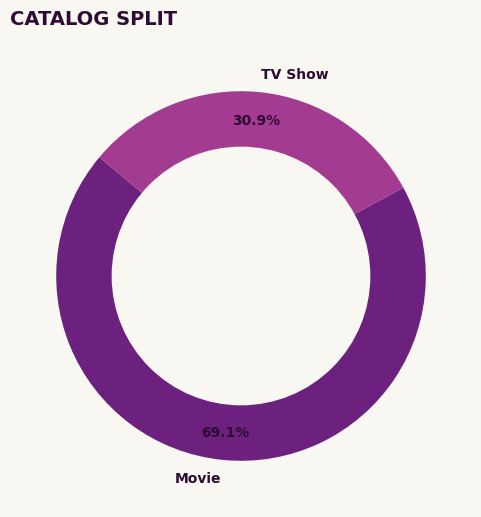

In [20]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor=CREAM)
type_counts = df['type'].value_counts()

ax.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', 
       colors=[GRAPE, ORCHID], startangle=140, pctdistance=0.85,
       textprops={'fontweight': 'bold', 'color': PLUM_DARK})

# Draw center circle to turn Pie into Donut
center_circle = plt.Circle((0,0), 0.70, fc=CREAM)
ax.add_artist(center_circle)
apply_berry_style(ax, 'Catalog Split')
plt.show()

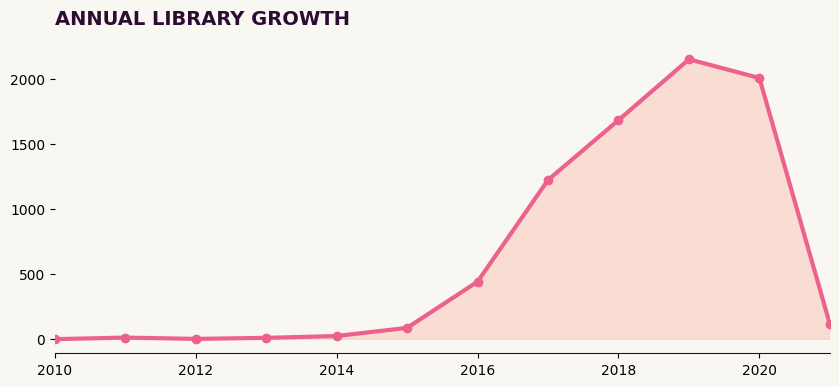

In [21]:
ig, ax = plt.subplots(figsize=(10, 4), facecolor=CREAM)
growth = df.groupby('year_added').size()

ax.fill_between(growth.index, growth.values, color=PEACH, alpha=0.4)
ax.plot(growth.index, growth.values, color=BERRY_PINK, lw=3, marker='o')
ax.set_xlim(2010, 2021)
apply_berry_style(ax, 'Annual Library Growth')
plt.show()

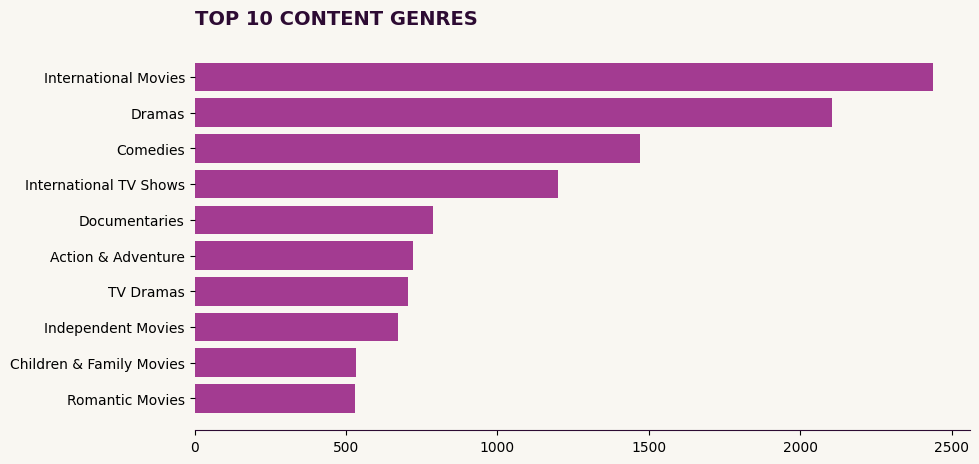

In [22]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor=CREAM)
genres = df['listed_in'].str.split(', ').explode().value_counts().head(10).sort_values()

ax.barh(genres.index, genres.values, color=ORCHID)
apply_berry_style(ax, 'Top 10 Content Genres')
plt.show()

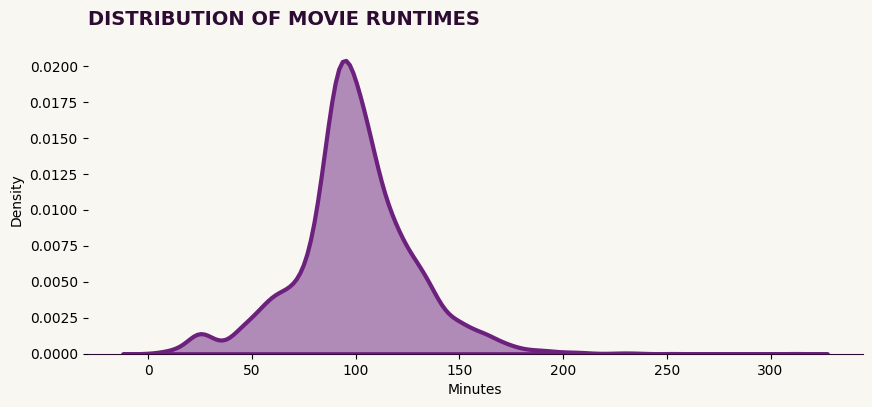

In [23]:
fig, ax = plt.subplots(figsize=(10, 4), facecolor=CREAM)
movies = df[df['type']=='Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)

sns.kdeplot(movies['duration_min'], fill=True, color=GRAPE, ax=ax, lw=3, alpha=0.5)
apply_berry_style(ax, 'Distribution of Movie Runtimes')
ax.set_xlabel('Minutes')
plt.show()

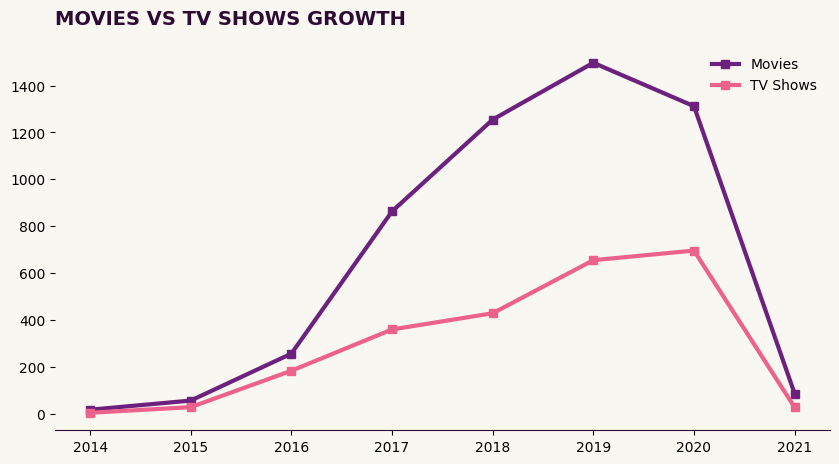

In [24]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor=CREAM)
trend = df[df['year_added'] >= 2014].groupby(['year_added', 'type']).size().unstack().fillna(0)

ax.plot(trend.index, trend['Movie'], color=GRAPE, lw=3, label='Movies', marker='s')
ax.plot(trend.index, trend['TV Show'], color=BERRY_PINK, lw=3, label='TV Shows', marker='s')

ax.legend(frameon=False)
apply_berry_style(ax, 'Movies vs TV Shows Growth')
plt.show()

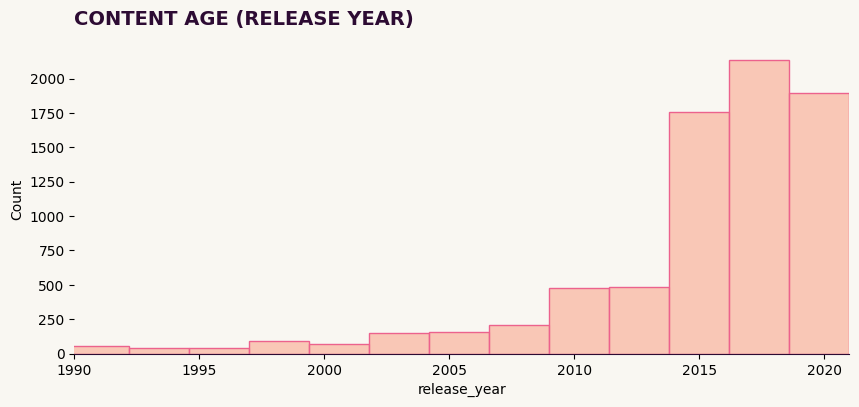

In [25]:
fig, ax = plt.subplots(figsize=(10, 4), facecolor=CREAM)
sns.histplot(df['release_year'], bins=40, ax=ax, color=PEACH, edgecolor=BERRY_PINK)

ax.set_xlim(1990, 2021) # Focusing on modern era
apply_berry_style(ax, 'Content Age (Release Year)')
plt.show()

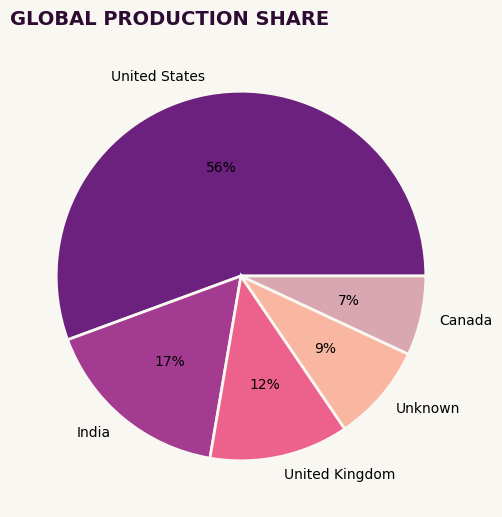

In [26]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor=CREAM)
share = df['country'].str.split(', ').explode().value_counts().head(5)

ax.pie(share, labels=share.index, autopct='%1.0f%%', 
       colors=[GRAPE, ORCHID, BERRY_PINK, PEACH, "#D8A7B1"],
       wedgeprops={'edgecolor': CREAM, 'linewidth': 2})

apply_berry_style(ax, 'Global Production Share')
plt.show()